**Toy Dataset Functions**

In [1]:
import math
import random
from typing import List, Dict, Any


def _sigmoid(x: float) -> float:
    return 1.0 / (1.0 + math.exp(-x))


def _logit(p: float) -> float:
    return math.log(p / (1.0 - p))


def p_series_from_flips(
    initial_p_head: float,
    flips: List[int],
    regimes: List[str] | None = None,
    latent_step: float = 0.4,
    mean_reversion: float = 0.30,
    lower: float = 0.25,
    upper: float = 0.75,
) -> List[float]:
    """
    Reconstruct p_head_before at each timestep from initial_p_head and flip history.

    If regimes is omitted, assumes pure trend-updown dynamics.
    If regimes is provided, reconstruction is exact for the deterministic two-regime generator.
    """
    if not (lower < initial_p_head < upper):
        raise ValueError("initial_p_head must be strictly between lower and upper")

    if regimes is not None and len(regimes) != len(flips):
        raise ValueError("regimes must have the same length as flips")

    span = upper - lower
    z = _logit((initial_p_head - lower) / span)
    p_before = []

    for idx, flip in enumerate(flips):
        p_before.append(lower + span * _sigmoid(z))

        if regimes is None:
            z = z + latent_step * flip
            continue

        regime = regimes[idx]
        if regime == "trend_updown":
            z = z + latent_step * flip
        elif regime == "mean_reverting":
            z = (1.0 - mean_reversion) * z + latent_step * flip
        else:
            raise ValueError(f"Unknown regime: {regime}")

    return p_before


def reconstruct_steps_from_flips_and_regimes(
    initial_p_head: float,
    flips: List[int],
    regimes: List[str],
    latent_step: float = 0.4,
    mean_reversion: float = 0.30,
    lower: float = 0.25,
    upper: float = 0.75,
) -> List[Dict[str, Any]]:
    """
    Reconstruct full step records exactly from initial p, flips, and recorded regimes.
    """
    if len(regimes) != len(flips):
        raise ValueError("regimes must have the same length as flips")

    span = upper - lower
    z = _logit((initial_p_head - lower) / span)
    steps: List[Dict[str, Any]] = []

    for t, (flip, regime) in enumerate(zip(flips, regimes)):
        p_before = lower + span * _sigmoid(z)

        if regime == "trend_updown":
            z = z + latent_step * flip
        elif regime == "mean_reverting":
            z = (1.0 - mean_reversion) * z + latent_step * flip
        else:
            raise ValueError(f"Unknown regime: {regime}")

        p_after = lower + span * _sigmoid(z)
        steps.append({
            "t": t,
            "p_head_before": p_before,
            "flip": flip,
            "p_head_after": p_after,
            "regime": regime,
        })

    return steps


def generate_nonstationary_coin_flips(n: int, seed: int | None = None) -> Dict[str, Any]:
    """
    Generate non-stationary coin flips with deterministic two-regime switching.

    Regimes:
    - trend_updown: original dynamics, z <- z + latent_step * flip
    - mean_reverting: z <- (1 - mean_reversion) * z + latent_step * flip

    Deterministic regime switching by current p (hysteresis):
    - switch to mean_reverting if p >= 0.70 or p <= 0.30
    - switch to trend_updown if 0.45 < p < 0.55

    Returns:
        {
            'initial_p_head': float,
            'flips': List[int],
            'flip_symbols': List[str],
            'steps': List[Dict[str, float | int | str]]
        }
    """
    if not isinstance(n, int) or n <= 0:
        raise ValueError("n must be a positive integer")

    rng = random.Random(seed)

    lower, upper = 0.25, 0.75
    span = upper - lower
    latent_step = 0.4
    mean_reversion = 0.30

    p_head = rng.uniform(0.40, 0.60)
    initial_p_head = p_head

    z = _logit((p_head - lower) / span)
    regime = "trend_updown"

    flips: List[int] = []
    symbols: List[str] = []
    steps: List[Dict[str, Any]] = []

    for t in range(n):
        p_before = lower + span * _sigmoid(z)

        if p_before >= 0.70 or p_before <= 0.30:
            regime = "mean_reverting"
        elif 0.45 < p_before < 0.55:
            regime = "trend_updown"

        is_head = 1 if rng.random() < p_before else -1

        flips.append(is_head)
        symbols.append("H" if is_head == 1 else "T")

        if regime == "trend_updown":
            z = z + latent_step * is_head
        else:
            z = (1.0 - mean_reversion) * z + latent_step * is_head

        p_after = lower + span * _sigmoid(z)

        steps.append({
            "t": t,
            "p_head_before": p_before,
            "flip": is_head,
            "p_head_after": p_after,
            "regime": regime,
        })

    return {
        "initial_p_head": initial_p_head,
        "flips": flips,
        "flip_symbols": symbols,
        "steps": steps,
    }


In [2]:
def build_autoregressive_dataset(
    n: int,
    k: int,
    seed: int | None = None,
    include_p_true: bool = False,
):
    """
    Build autoregressive windows from generated flips.

    If include_p_true=True, also returns p_head_before aligned with each target y.
    """
    sim = generate_nonstationary_coin_flips(n=n, seed=seed)
    flips = sim["flips"]
    p_before = [s["p_head_before"] for s in sim["steps"]]

    X = []
    y = []
    p_true = []

    for t in range(k, len(flips)):
        X.append(flips[t-k:t])   # past k flips, signed {-1, +1}
        y.append(flips[t])       # next flip, signed {-1, +1}
        if include_p_true:
            p_true.append(p_before[t])

    if include_p_true:
        return X, y, p_true
    return X, y

In [3]:
# Example usage
sample = generate_nonstationary_coin_flips(20)
print("Initial p(head):", round(sample["initial_p_head"], 3))
print("Flip symbols:", "".join(sample["flip_symbols"]))
print("First 5 step records:")
for row in sample["steps"][:5]:
    print(row)

train_rows = build_autoregressive_dataset(10, k =5)
print("\nFirst 3 training rows:")
for row in train_rows[:3]:
    print(row)

Initial p(head): 0.468
Flip symbols: TTTTHTTTHTTHTHHTTTTT
First 5 step records:
{'t': 0, 'p_head_before': 0.4675016395402318, 'flip': -1, 'p_head_after': 0.42020514573469997, 'regime': 'trend_updown'}
{'t': 1, 'p_head_before': 0.42020514573469997, 'flip': -1, 'p_head_after': 0.37851466573229836, 'regime': 'trend_updown'}
{'t': 2, 'p_head_before': 0.37851466573229836, 'flip': -1, 'p_head_after': 0.34412157599318804, 'regime': 'trend_updown'}
{'t': 3, 'p_head_before': 0.34412157599318804, 'flip': -1, 'p_head_after': 0.31726611374676894, 'regime': 'trend_updown'}
{'t': 4, 'p_head_before': 0.31726611374676894, 'flip': 1, 'p_head_after': 0.34412157599318804, 'regime': 'trend_updown'}

First 3 training rows:
[[1, 1, -1, -1, 1], [1, -1, -1, 1, -1], [-1, -1, 1, -1, -1], [-1, 1, -1, -1, -1], [1, -1, -1, -1, -1]]
[-1, -1, -1, -1, -1]


**Autoregressive MLP**

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [5]:
class FlipDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)

        y_tensor = torch.tensor(y, dtype=torch.float32)
        # Keep signed labels in the data pipeline, but map to {0,1} for BCE.
        y_binary = (y_tensor + 1.0) / 2.0

        self.y_signed = y_tensor.unsqueeze(1)
        self.y = y_binary.unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [6]:
class AutoregressiveMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.LeakyReLU(),
            nn.Linear(64, 64),
            nn.LeakyReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [7]:
def build_dataset_with_latent(n, k, seed=None):
    """
    Convenience wrapper that always returns p_true aligned with each y target.
    """
    return build_autoregressive_dataset(
        n=n,
        k=k,
        seed=seed,
        include_p_true=True,
    )

In [8]:
def train_model(model, dataloader, epochs=10, lr=1e-3):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        total_loss = 0

        for X_batch, y_batch in dataloader:
            preds = model(X_batch)
            loss = criterion(preds, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

In [9]:
# Hyperparameters
n = 5000
k = 20
batch_size = 64

# Build dataset (with latent p_true aligned to targets)
X, y, p_true_train = build_dataset_with_latent(n=n, k=k, seed=42)

dataset = FlipDataset(X, y)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Model
model = AutoregressiveMLP(input_dim=k)

# Train
train_model(model, loader, epochs=20)

Epoch 1, Loss: 53.0267
Epoch 2, Loss: 52.0921
Epoch 3, Loss: 51.7078
Epoch 4, Loss: 51.5056
Epoch 5, Loss: 51.2645
Epoch 6, Loss: 51.0638
Epoch 7, Loss: 50.8375
Epoch 8, Loss: 50.6204
Epoch 9, Loss: 50.3756
Epoch 10, Loss: 50.0217
Epoch 11, Loss: 49.7495
Epoch 12, Loss: 49.3731
Epoch 13, Loss: 49.0041
Epoch 14, Loss: 48.7336
Epoch 15, Loss: 48.3785
Epoch 16, Loss: 47.8111
Epoch 17, Loss: 47.4986
Epoch 18, Loss: 46.9941
Epoch 19, Loss: 46.5483
Epoch 20, Loss: 46.0636


In [10]:
def get_model_probability_outputs(model, X):
    """
    Return raw model probabilities for each input window in X.

    Note: for binary classification this is sigmoid output (softmax-equivalent).
    """
    model.eval()

    preds = []
    with torch.no_grad():
        for x in X:
            xt = torch.tensor(x, dtype=torch.float32).unsqueeze(0)
            preds.append(model(xt).item())

    return preds

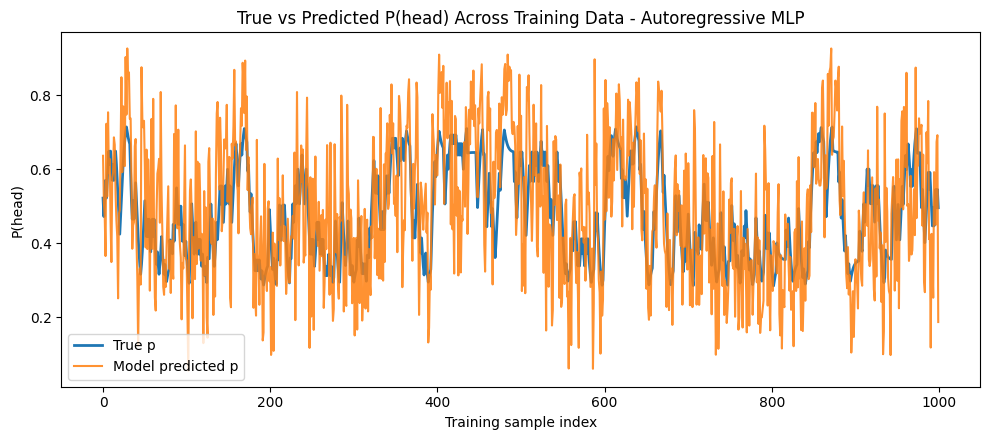

In [14]:
def plot_true_vs_pred_p_over_samples(model, X, p_true, max_points=None):
    """
    Plot true latent p and model-predicted p over sample index.

    Args:
        model: trained model
        X: autoregressive input windows
        p_true: true p_head_before aligned with targets
        max_points: optionally limit number of points for readability
    """
    import matplotlib.pyplot as plt

    p_pred = get_model_probability_outputs(model, X)

    if max_points is not None:
        X_plot = list(range(min(max_points, len(p_true))))
        p_true_plot = p_true[:len(X_plot)]
        p_pred_plot = p_pred[:len(X_plot)]
    else:
        X_plot = list(range(len(p_true)))
        p_true_plot = p_true
        p_pred_plot = p_pred

    plt.figure(figsize=(10, 4.5))
    plt.plot(X_plot, p_true_plot, label="True p", linewidth=2)
    plt.plot(X_plot, p_pred_plot, label="Model predicted p", alpha=0.85)
    plt.xlabel("Training sample index")
    plt.ylabel("P(head)")
    plt.title("True vs Predicted P(head) Across Training Data - Autoregressive MLP")
    plt.legend()
    plt.tight_layout()
    plt.savefig("true_vs_pred_p_over_samples_autoregressive_mlp.png", dpi=300)
    plt.show()

    return p_pred


# Example: plot first 1000 samples for readability
p_pred_train = plot_true_vs_pred_p_over_samples(model, X, p_true_train, max_points=1000)

In [17]:
import importlib
import toy_data
import toy_data.plotting as toy_plotting
importlib.reload(toy_plotting)
importlib.reload(toy_data)
from toy_data import compute_true_vs_pred_metrics, save_metrics_comparison_table_png

# --- Train metrics (full dataset, not just the plotted 1000) ---
p_pred_all_train = get_model_probability_outputs(model, X)
metrics_train = compute_true_vs_pred_metrics(p_true_train, p_pred_all_train)

# --- Test split (independent seed) ---
X_test, y_test, p_true_test = build_dataset_with_latent(n=n, k=k, seed=314)
p_pred_test = get_model_probability_outputs(model, X_test)
metrics_test = compute_true_vs_pred_metrics(p_true_test, p_pred_test)

# --- Save a single combined PNG table ---
save_metrics_comparison_table_png(
    {'Train': metrics_train, 'Test': metrics_test},
    save_path='metrics_mlp_comparison.png',
)

print('           |   MAE   |  RMSE   |  Corr  ')
print('-----------|---------|---------|--------')
print('Train      | {:.4f}  | {:.4f}  | {:.4f} '.format(
    metrics_train['mae'], metrics_train['rmse'], metrics_train['corr']
))
print('Test       | {:.4f}  | {:.4f}  | {:.4f} '.format(
    metrics_test['mae'], metrics_test['rmse'], metrics_test['corr']
))
print()
print('Saved: metrics_mlp_comparison.png')

           |   MAE   |  RMSE   |  Corr  
-----------|---------|---------|--------
Train      | 0.1214  | 0.1500  | 0.6358 
Test       | 0.1169  | 0.1440  | 0.6626 

Saved: metrics_mlp_comparison.png


In [12]:
# Reusable package usage (works from other notebooks in this same project folder)
from toy_data.generation import generate_nonstationary_coin_flips
from toy_data.adapters import (
    build_autoregressive_dataset,
    build_sequence_dataset,
)

# 1) Fixed-window dataset (MLP/CNN style)
X_win, y_win, p_true_win = build_autoregressive_dataset(
    n=200,
    k=20,
    seed=123,
    include_p_true=True,
)
print("Window dataset sizes:", len(X_win), len(y_win), len(p_true_win))

# 2) Variable-length sequence dataset (RNN/GRU/LSTM/Transformer style)
seq = build_sequence_dataset(n=200, seed=123)
print("Sequence input length:", len(seq["x_seq"]))
print("Sequence target length:", len(seq["y_flip_next"]))
print("Keys:", list(seq.keys()))

# 3) Full raw simulation access
sim_pkg = generate_nonstationary_coin_flips(20, seed=7)
print("First 3 regimes:", [s["regime"] for s in sim_pkg["steps"][:3]])

Window dataset sizes: 180 180 180
Sequence input length: 199
Sequence target length: 199
Keys: ['initial_p_head', 'x_seq', 'y_flip_next', 'y_p_next', 'regime_next', 'full_flips', 'full_p', 'full_regimes']
First 3 regimes: ['trend_updown', 'trend_updown', 'trend_updown']
